In [1]:
# Netflix EDA — Data Exploration
## Business Questions We Will Answer:
1. How many Movies vs TV Shows does Netflix have?
2. Which countries produce the most Netflix content?
3. How has Netflix grown over the years?
4. What are the most popular genres?
5. Which ratings dominate the platform?


Object `have` not found.
Object `content` not found.
Object `years` not found.
Object `genres` not found.
Object `platform` not found.


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

# Import our custom functions
from src.data_loader import load_netflix_data, get_basic_info
from src.utils import (clean_column_names, 
                       extract_year_from_date,
                       extract_month_from_date,
                       split_listed_in)
from src.visualizations import set_netflix_style, plot_bar, plot_line, save_figure

print("✅ All libraries imported successfully!")

B
✅ All libraries imported successfully!


In [3]:
# Load the Netflix dataset
df = load_netflix_data("../data/raw/netflix_titles.csv")

Dataset loaded successfully!
shape: (8807, 12)


In [4]:
# Get basic information about the dataset
get_basic_info(df)

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
descr

In [5]:
# Clean column names and extract date features
df = clean_column_names(df)
df = extract_year_from_date(df, "date_added")
df = extract_month_from_date(df, "date_added")

print("✅ Data cleaned successfully!")
print(f"New columns added: {[col for col in df.columns if 'date_added' in col]}")

✅ Data cleaned successfully!
New columns added: ['date_added', 'date_added_year', 'date_added_month']


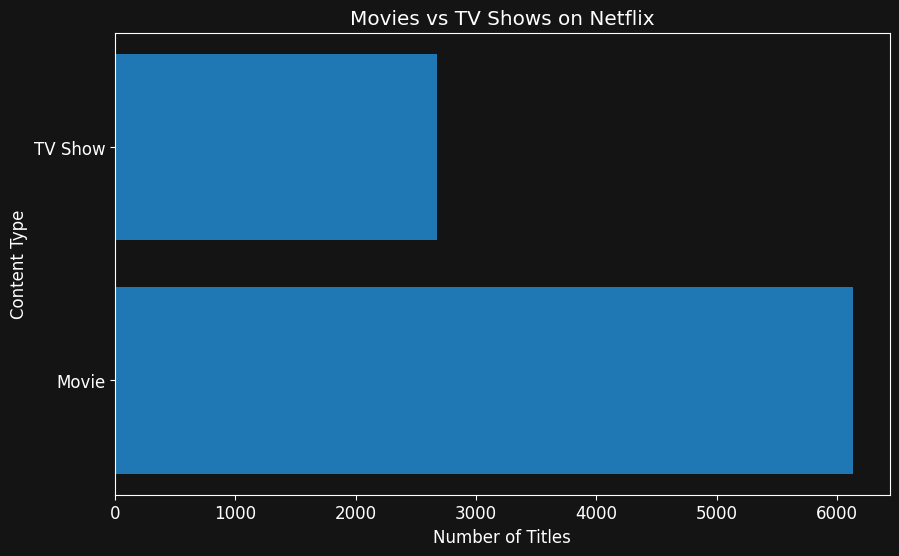

In [6]:
# Business Question 1:
# How many Movies vs TV Shows does Netflix have?

set_netflix_style()

data = df['type'].value_counts()
plot_bar(
    data   = data,
    title  = "Movies vs TV Shows on Netflix",
    xlabel = "Number of Titles",
    ylabel = "Content Type"
)
save_figure("01_content_type.png")
plt.show()

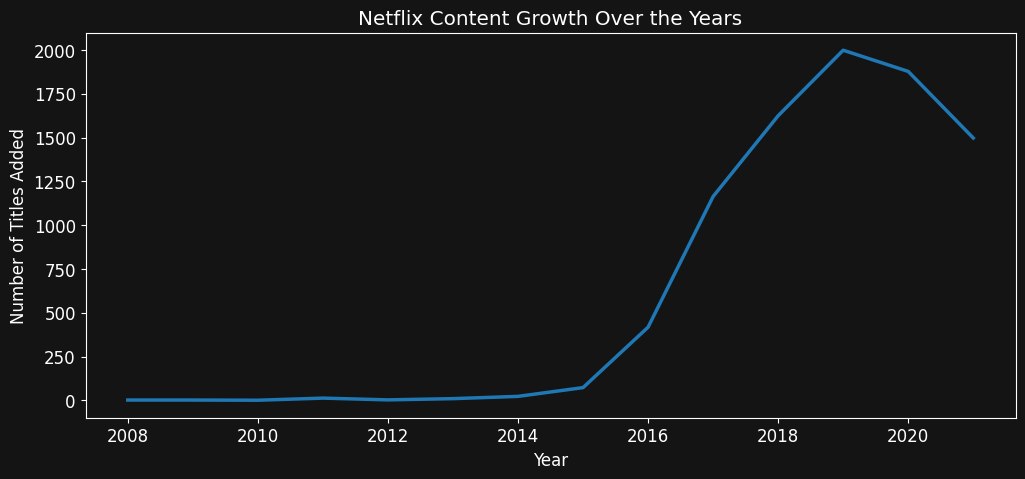

In [7]:
# Business Question 2:
# How has Netflix grown over the years?

data = df['date_added_year'].value_counts().sort_index()

plot_line(
    x      = data.index,
    y      = data.values,
    title  = "Netflix Content Growth Over the Years",
    xlabel = "Year",
    ylabel = "Number of Titles Added"
)
save_figure("02_growth_over_years.png")
plt.show()

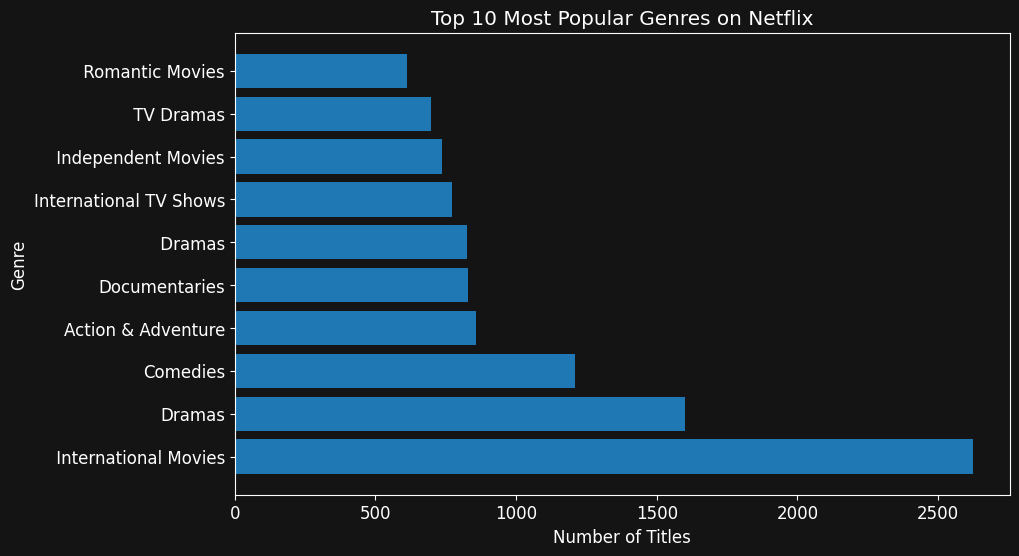

In [8]:
# Business Question 3:
# What are the most popular genres on Netflix?

df_genres = split_listed_in(df)
data = df_genres['genre'].value_counts().head(10)

plot_bar(
    data   = data,
    title  = "Top 10 Most Popular Genres on Netflix",
    xlabel = "Number of Titles",
    ylabel = "Genre"
)
save_figure("03_top_genres.png")
plt.show()

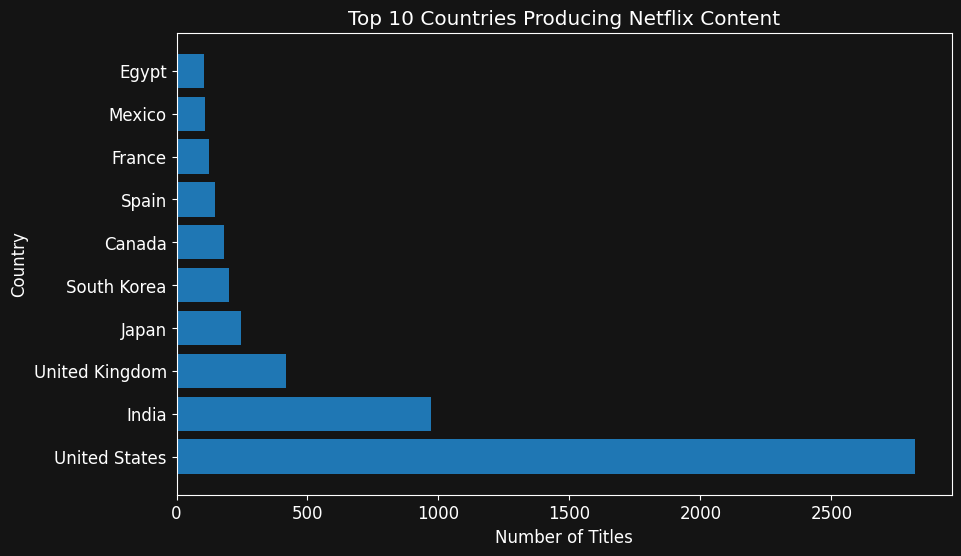

In [9]:
# Business Question 4:
# Which countries produce the most Netflix content?

data = df['country'].value_counts().head(10)

plot_bar(
    data   = data,
    title  = "Top 10 Countries Producing Netflix Content",
    xlabel = "Number of Titles",
    ylabel = "Country"
)
save_figure("04_top_countries.png")
plt.show()

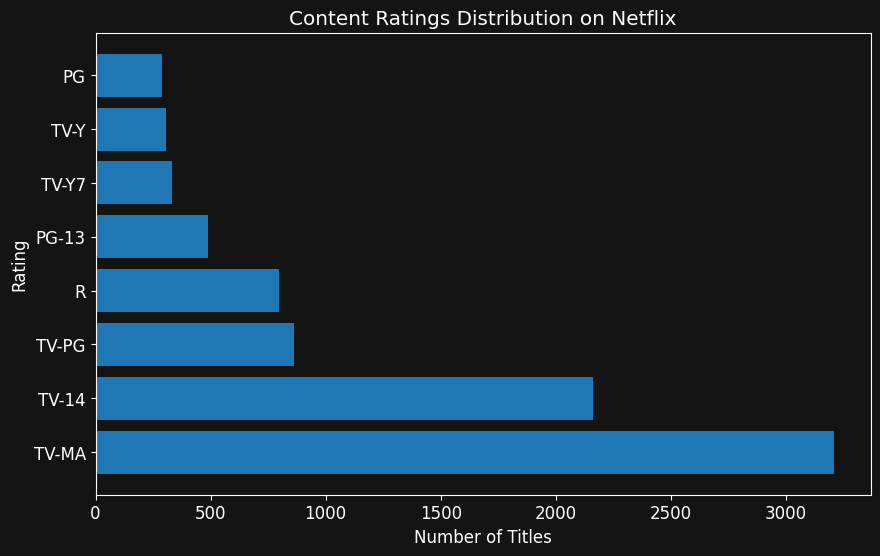

In [10]:
# Business Question 5:
# Which content ratings dominate Netflix?

data = df['rating'].value_counts().head(8)

plot_bar(
    data   = data,
    title  = "Content Ratings Distribution on Netflix",
    xlabel = "Number of Titles",
    ylabel = "Rating"
)
save_figure("05_ratings.png")
plt.show()

In [ ]:
# ═══════════════════════════════════════
# KEY BUSINESS INSIGHTS SUMMARY
# ═══════════════════════════════════════

insights = """
📊 NETFLIX DATA ANALYSIS — KEY FINDINGS
========================================

1. CONTENT TYPE
   → Netflix has 2.4x more Movies than TV Shows
   → Movies: ~6000 titles | TV Shows: ~2500 titles

2. GROWTH TREND  
   → Netflix grew explosively from 2015 to 2019
   → Peak year: 2019 with 2000+ titles added
   → Post-2019 drop likely due to COVID-19

3. TOP GENRES
   → International Movies dominate with 2600+ titles
   → Dramas and Comedies follow at 1600 and 1200
   → Strong focus on global diverse content

4. TOP COUNTRIES
   → USA leads with 2800+ titles
   → India is #2 globally with 1000+ titles
   → Shows Netflix's massive investment in Asian content

5. CONTENT RATINGS
   → TV-MA dominates — Netflix targets mature audiences
   → 36% of all content is for adults only
   → Clear strategy to differentiate from Disney+
"""

print(insights)